In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/supplement-sales-data/Supplement_Sales_Weekly_Expanded.csv


In [2]:
df = pd.read_csv('/kaggle/input/supplement-sales-data/Supplement_Sales_Weekly_Expanded.csv')

In [3]:
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [4]:
df.shape

(4384, 10)

In [5]:
df[['ano', 'mes', 'dia']] = df['Date'].str.split('-', expand=True)

In [6]:
df=df.drop(columns=['Date'])

print(df)

            Product Name     Category  Units Sold  Price  Revenue  Discount  \
0           Whey Protein      Protein         143  31.98  4573.14      0.03   
1              Vitamin C      Vitamin         139  42.51  5908.89      0.04   
2               Fish Oil        Omega         161  12.91  2078.51      0.25   
3           Multivitamin      Vitamin         140  16.07  2249.80      0.08   
4            Pre-Workout  Performance         157  35.47  5568.79      0.25   
...                  ...          ...         ...    ...      ...       ...   
4379           Melatonin    Sleep Aid         160  47.79  7646.40      0.21   
4380              Biotin      Vitamin         154  38.12  5870.48      0.22   
4381   Green Tea Extract   Fat Burner         139  20.40  2835.60      0.12   
4382     Iron Supplement      Mineral         154  18.31  2819.74      0.23   
4383  Electrolyte Powder    Hydration         178  39.12  6963.36      0.23   

      Units Returned Location Platform   ano mes di

In [7]:
df.isnull().sum()

Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
ano               0
mes               0
dia               0
dtype: int64

In [8]:
df['ano'] = df['ano'].astype(int)
df['mes'] = df['mes'].astype(int)
df['dia'] = df['dia'].astype(int)

df = df.rename(columns={'ano': 'year', 'mes': 'month', 'dia': 'day'})

df['data_completa'] = pd.to_datetime(df[['year', 'month', 'day']])

# Quantidade de produtos vendidos ao longo dos anos

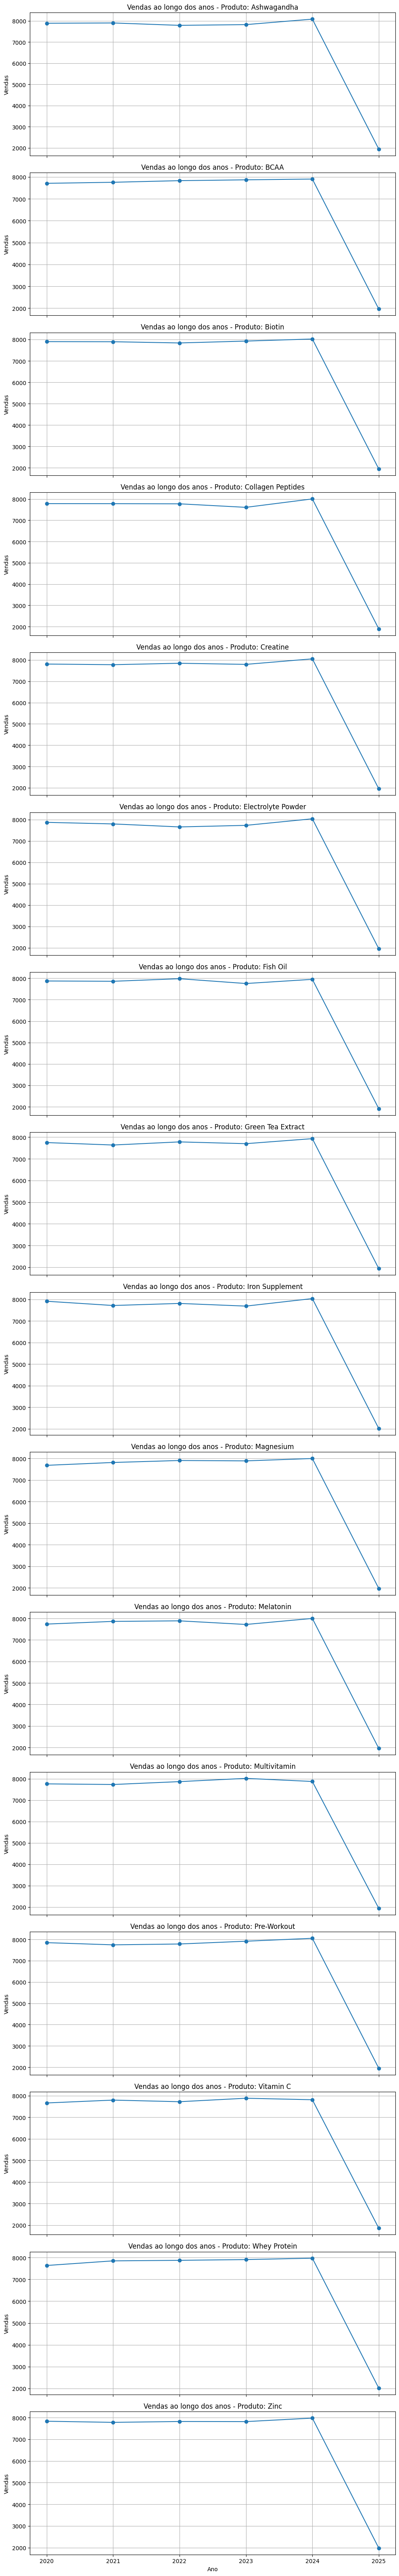

In [9]:
# Agrupa os dados por ano e produto
vendas_por_produto_ano = df.groupby(['year', 'Product Name'])['Units Sold'].sum().reset_index()

# Lista de produtos únicos
produtos = vendas_por_produto_ano['Product Name'].unique()

# Número de produtos = número de subplots
n = len(produtos)

# Define o tamanho da figura geral (ajusta conforme o número de produtos)
fig, axs = plt.subplots(n, 1, figsize=(10, 4 * n), sharex=True)

# Garante que axs é sempre uma lista (mesmo se for só 1 subplot)
if n == 1:
    axs = [axs]

# Loop para criar um gráfico para cada produto
for i, produto in enumerate(produtos):
    data_produto = vendas_por_produto_ano[vendas_por_produto_ano['Product Name'] == produto]
    axs[i].plot(data_produto['year'], data_produto['Units Sold'], marker='o', color='tab:blue')
    axs[i].set_title(f'Vendas ao longo dos anos - Produto: {produto}')
    axs[i].set_ylabel('Vendas')
    axs[i].grid(True)

# Ajusta layout
plt.xlabel('Ano')
plt.tight_layout()
plt.show()


# Quantidade de devoluções ao longo dos anos

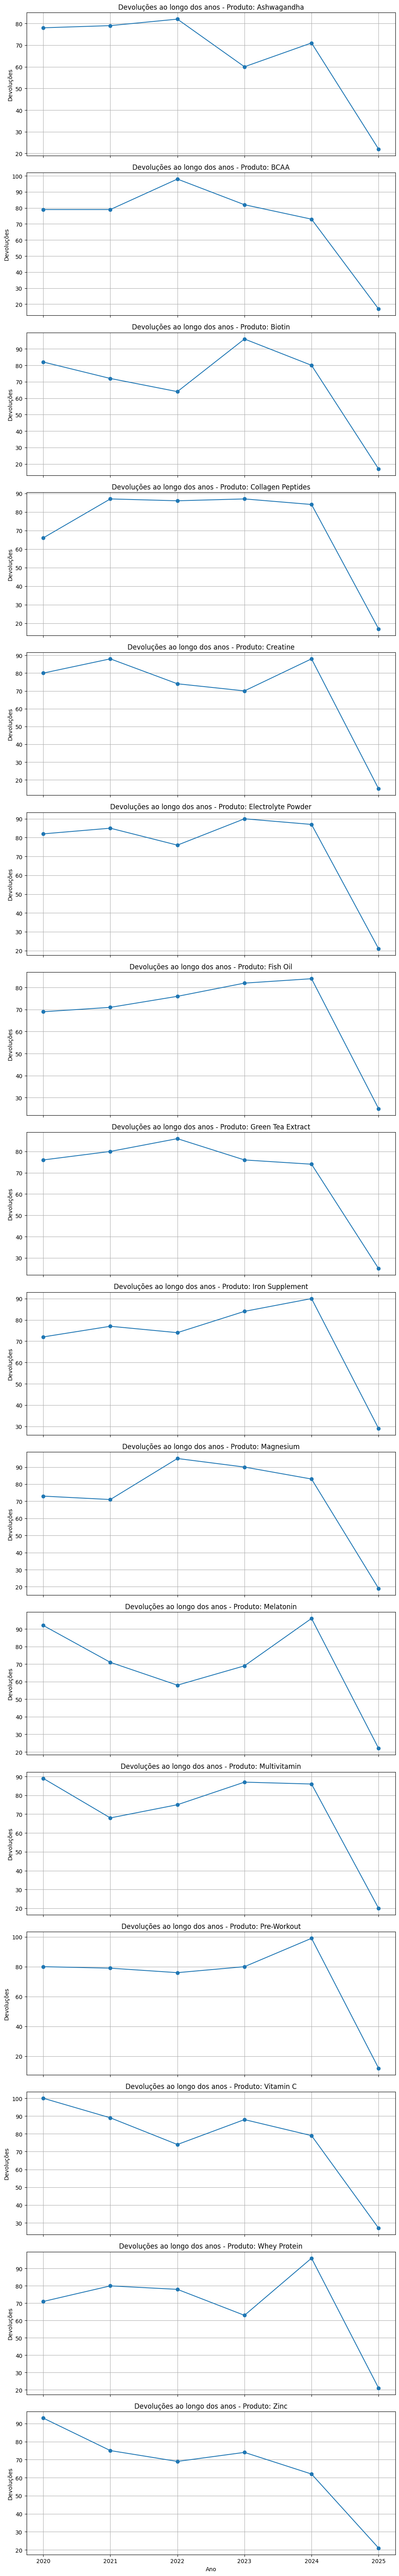

In [10]:
# Agrupa os dados por ano e produto
devolucoes_por_ano = df.groupby(['year', 'Product Name'])['Units Returned'].sum().reset_index()

# Lista de produtos únicos
produtos = devolucoes_por_ano['Product Name'].unique()

# Número de produtos = número de subplots
n = len(produtos)

# Define o tamanho da figura geral (ajusta conforme o número de produtos)
fig, axs = plt.subplots(n, 1, figsize=(10, 4 * n), sharex=True)

# Garante que axs é sempre uma lista (mesmo se for só 1 subplot)
if n == 1:
    axs = [axs]

# Loop para criar um gráfico para cada produto
for i, produto in enumerate(produtos):
    data_produto = devolucoes_por_ano[devolucoes_por_ano['Product Name'] == produto]
    axs[i].plot(data_produto['year'], data_produto['Units Returned'], marker='o', color='tab:blue')
    axs[i].set_title(f'Devoluções ao longo dos anos - Produto: {produto}')
    axs[i].set_ylabel('Devoluções')
    axs[i].grid(True)

# Ajusta layout
plt.xlabel('Ano')
plt.tight_layout()
plt.show()


# Vamos encontrar a receita per feriado regioanl

In [11]:
df['Location'].unique()

array(['Canada', 'UK', 'USA'], dtype=object)

In [12]:
df.head()

,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,year,month,day,data_completa
0,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart,2020,1,6,2020-01-06
1,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon,2020,1,6,2020-01-06
2,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon,2020,1,6,2020-01-06
3,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart,2020,1,6,2020-01-06
4,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb,2020,1,6,2020-01-06


In [13]:
# Exibir as primeiras linhas para checar
print(df[['data_completa', 'Location', 'Product Name', 'Revenue']].head())

feriados_canada = [
                     '2020-07-01', '2020-10-12', '2020-12-25', '2020-10-11',
                     '2021-07-01', '2021-10-12', '2021-12-25', '2021-10-11',
                     '2022-07-01', '2022-10-12', '2022-12-25', '2022-10-11',
                     '2023-07-01', '2023-10-12', '2023-12-25', '2023-10-11',
                     '2024-07-01', '2024-10-12', '2024-12-25', '2024-10-11'
]

feriados_usa = [
                     '2020-07-04', '2020-11-26', '2020-11-25', '2020-12-25',
                     '2021-07-04', '2021-11-26', '2021-11-25', '2021-12-25',
                     '2022-07-04', '2022-11-26', '2022-11-25', '2022-12-25',
                     '2023-07-04', '2023-11-26', '2023-11-25', '2023-12-25',
                     '2024-07-04', '2024-11-26', '2024-11-25', '2024-12-25'
]

feriados_uk = [
                     '2020-08-31', '2020-12-25', '2020-08-30',
                     '2021-08-31', '2021-12-25', '2021-08-30',
                     '2022-08-31', '2022-12-25', '2022-08-30',
                     '2023-08-31', '2023-12-25', '2023-08-30',
                     '2024-08-31', '2024-12-25', '2024-08-30'
]

# Função para verificar se a data é um feriado no país
def verificar_feriado(row):
    if row['Location'] == 'Canada' and row['data_completa'].strftime('%Y-%m-%d') in feriados_canada:
        return 'Feriado Canadá'
    elif row['Location'] == 'USA' and row['data_completa'].strftime('%Y-%m-%d') in feriados_usa:
        return 'Feriado EUA'
    elif row['Location'] == 'UK' and row['data_completa'].strftime('%Y-%m-%d') in feriados_uk:
        return 'Feriado UK'
    return 'Não'

# Aplicar para identificar feriados
df['Feriado'] = df.apply(verificar_feriado, axis=1)

# Verifique os dados
print(df[['day', 'month', 'Location', 'Product Name', 'Revenue', 'Feriado']].head(10))

# Agora você pode fazer a análise por ano:

  data_completa Location  Product Name  Revenue
0    2020-01-06   Canada  Whey Protein  4573.14
1    2020-01-06       UK     Vitamin C  5908.89
2    2020-01-06   Canada      Fish Oil  2078.51
3    2020-01-06   Canada  Multivitamin  2249.80
4    2020-01-06   Canada   Pre-Workout  5568.79
   day  month Location       Product Name  Revenue Feriado
0    6      1   Canada       Whey Protein  4573.14     Não
1    6      1       UK          Vitamin C  5908.89     Não
2    6      1   Canada           Fish Oil  2078.51     Não
3    6      1   Canada       Multivitamin  2249.80     Não
4    6      1   Canada        Pre-Workout  5568.79     Não
5    6      1       UK               BCAA  6343.26     Não
6    6      1       UK           Creatine  4353.66     Não
7    6      1   Canada               Zinc  6861.96     Não
8    6      1      USA  Collagen Peptides  1611.12     Não
9    6      1   Canada          Magnesium  2781.84     Não


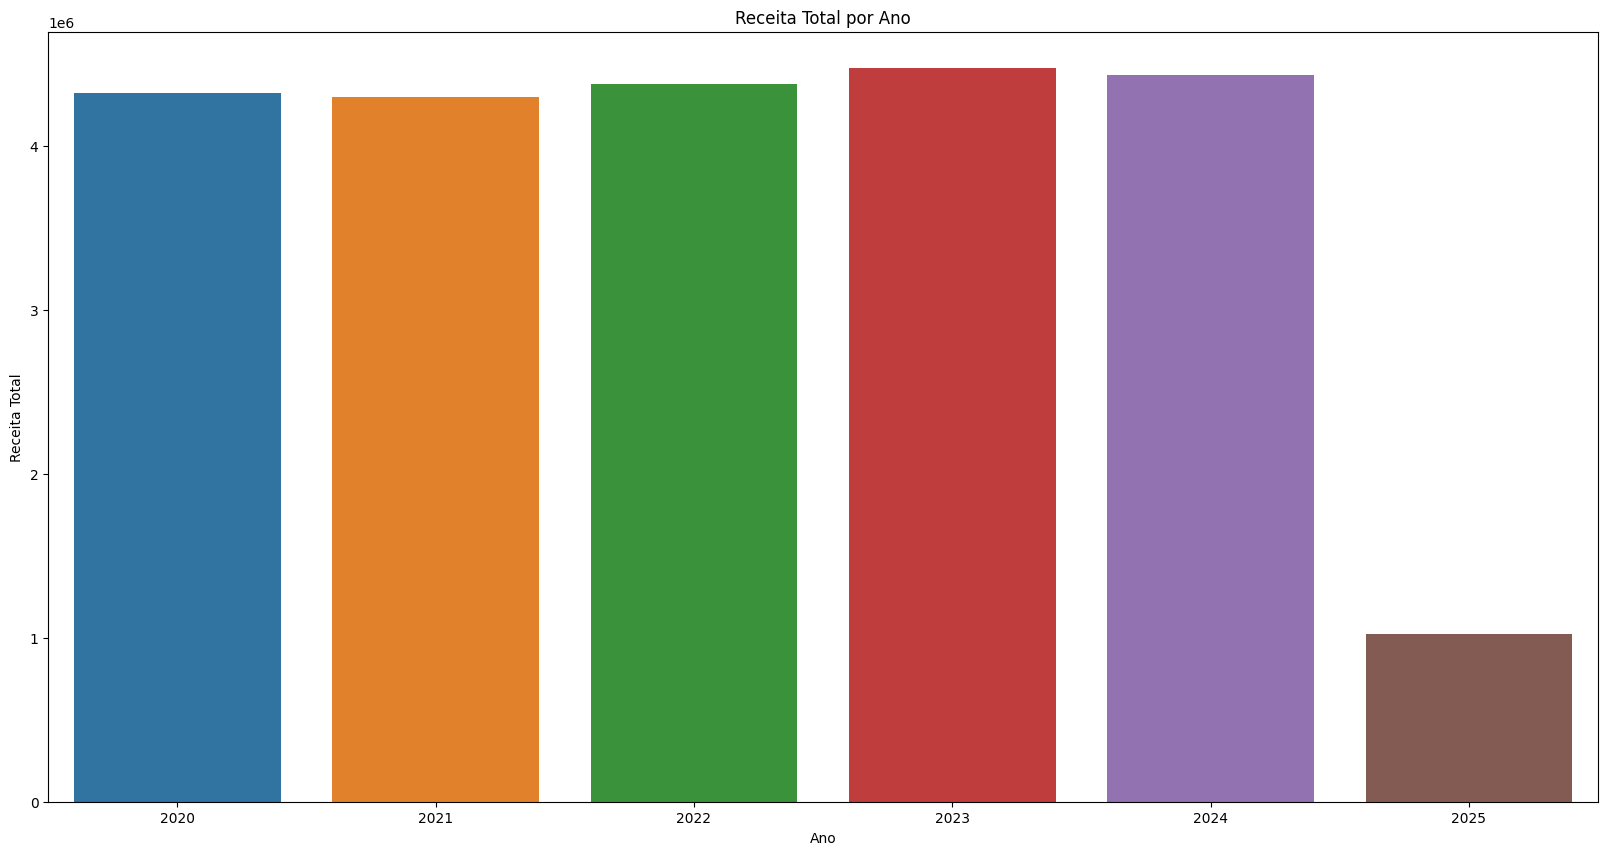

In [14]:
# Agrupar por ano e calcular a receita total
resumo_ano = df.groupby('year')['Revenue'].sum().reset_index()
plt.figure(figsize=(20, 10))
sns.barplot(x='year', y='Revenue', data=resumo_ano)
plt.title('Receita Total por Ano')
plt.ylabel('Receita Total')
plt.xlabel('Ano')
plt.show()

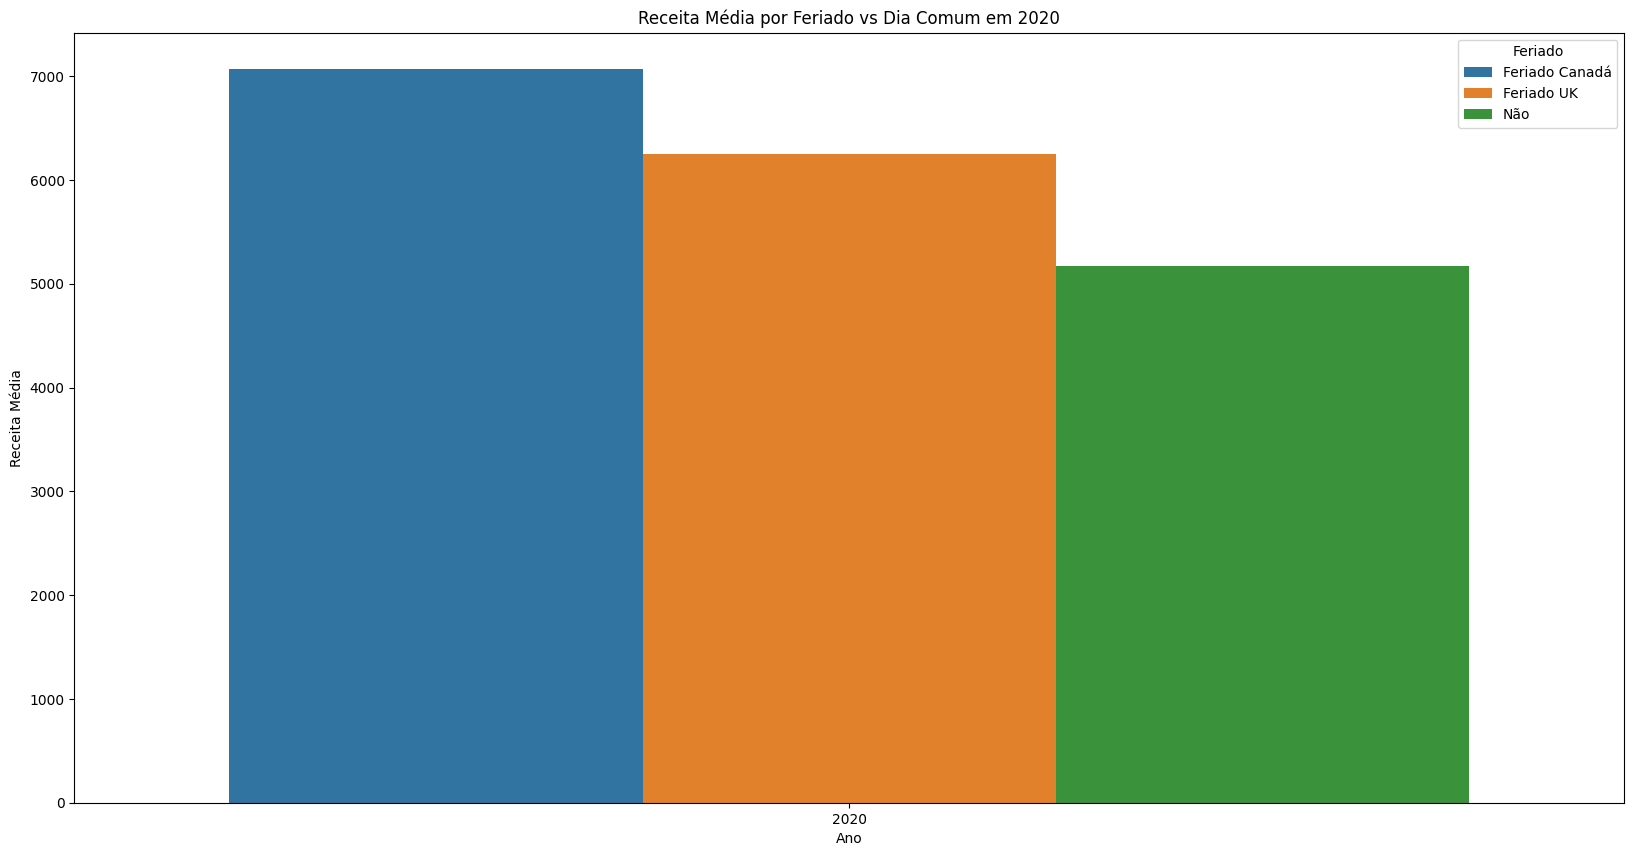

In [15]:
# Filtrar para considerar apenas o ano de 2020
df_2020 = df[df['year'] == 2020]

# Agrupar e calcular a receita média de 2020 por tipo de dia (feriado ou dia comum)
resumo_feriado_ano_2020 = df_2020.groupby(['year', 'Feriado'])['Revenue'].mean().reset_index()
plt.figure(figsize=(20, 10))
# Gráfico de receita média por feriado vs dia comum em 2020
sns.barplot(x='year', y='Revenue', hue='Feriado', data=resumo_feriado_ano_2020)
plt.title('Receita Média por Feriado vs Dia Comum em 2020')
plt.ylabel('Receita Média')
plt.xlabel('Ano')
plt.show()


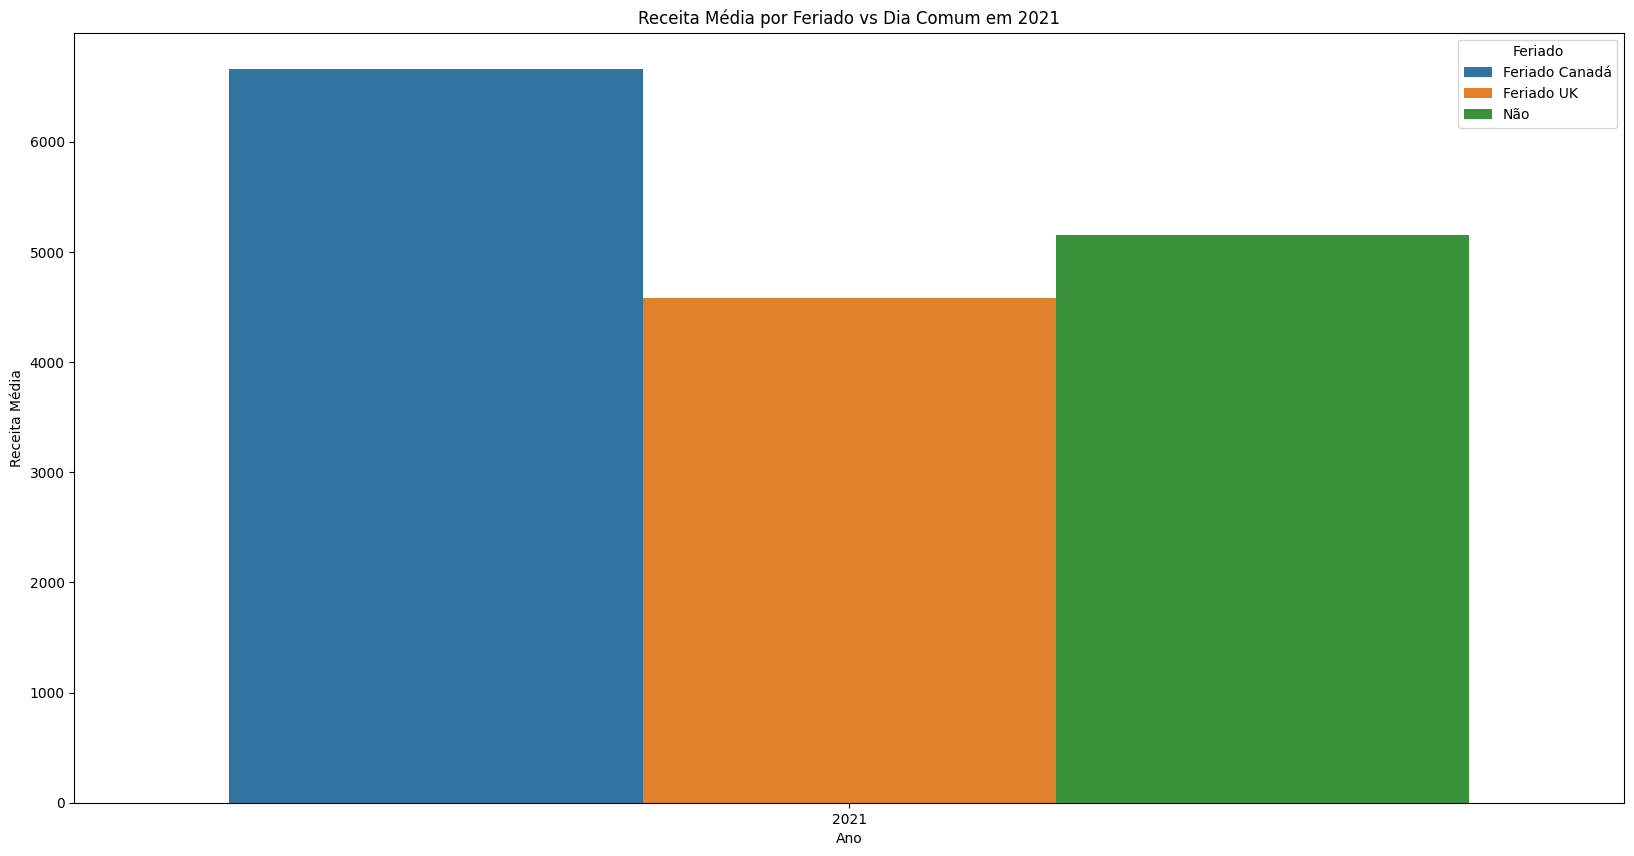

In [16]:
df_2021 = df[df['year'] == 2021]

resumo_feriado_ano_2021 = df_2021.groupby(['year', 'Feriado'])['Revenue'].mean().reset_index()
plt.figure(figsize=(20, 10))

sns.barplot(x='year', y='Revenue', hue='Feriado', data=resumo_feriado_ano_2021)
plt.title('Receita Média por Feriado vs Dia Comum em 2021')
plt.ylabel('Receita Média')
plt.xlabel('Ano')
plt.show()

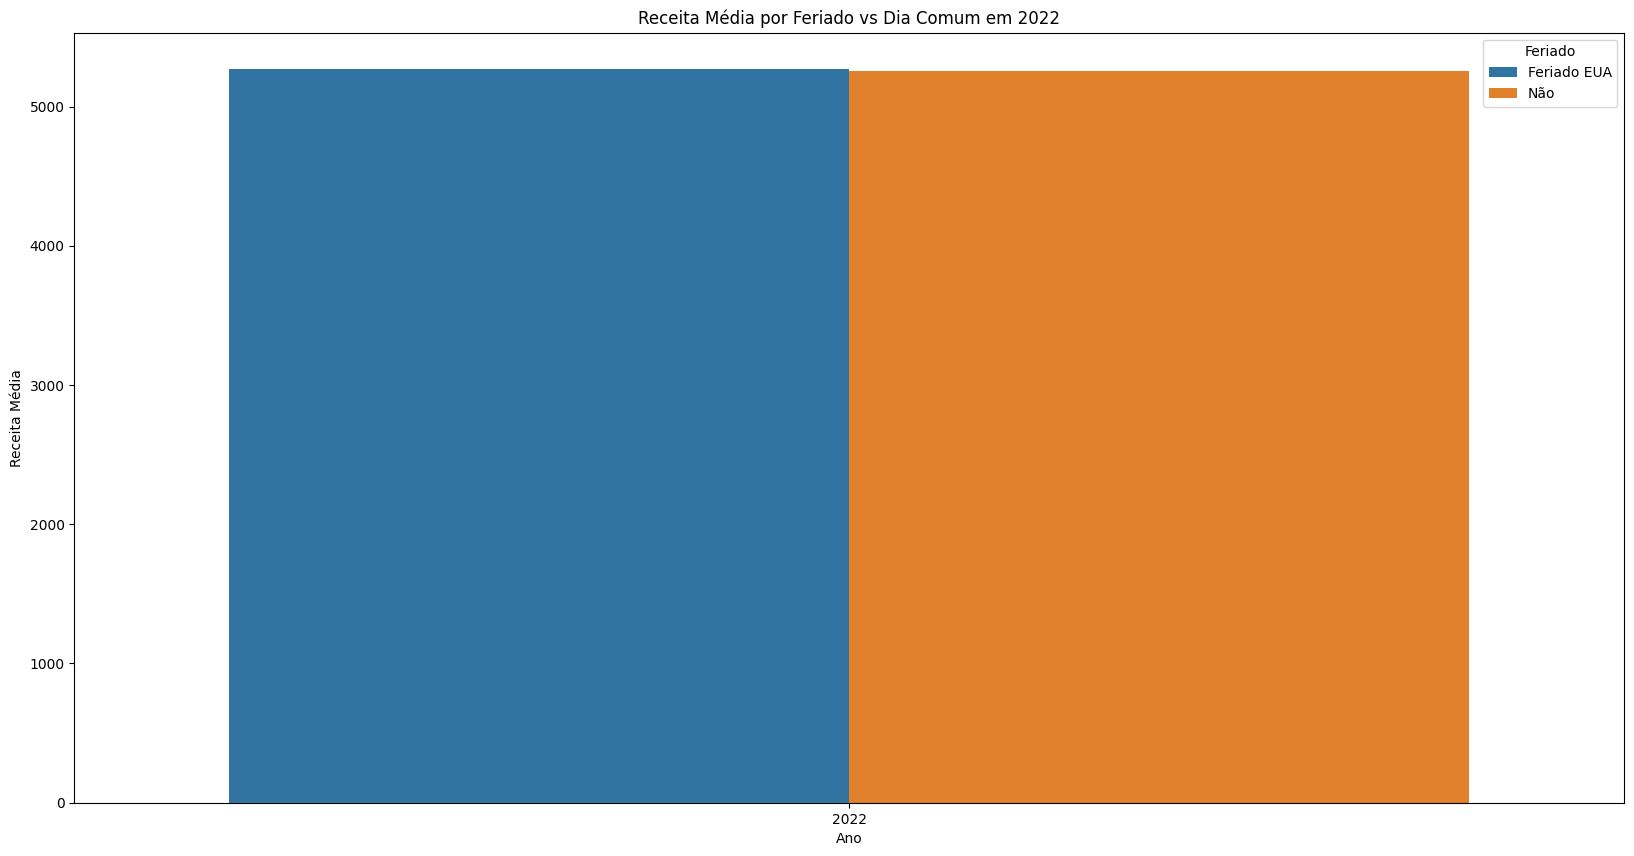

In [17]:
df_2022 = df[df['year'] == 2022]

resumo_feriado_ano_2022 = df_2022.groupby(['year', 'Feriado'])['Revenue'].mean().reset_index()
plt.figure(figsize=(20, 10))

sns.barplot(x='year', y='Revenue', hue='Feriado', data=resumo_feriado_ano_2022)
plt.title('Receita Média por Feriado vs Dia Comum em 2022')
plt.ylabel('Receita Média')
plt.xlabel('Ano')
plt.show()

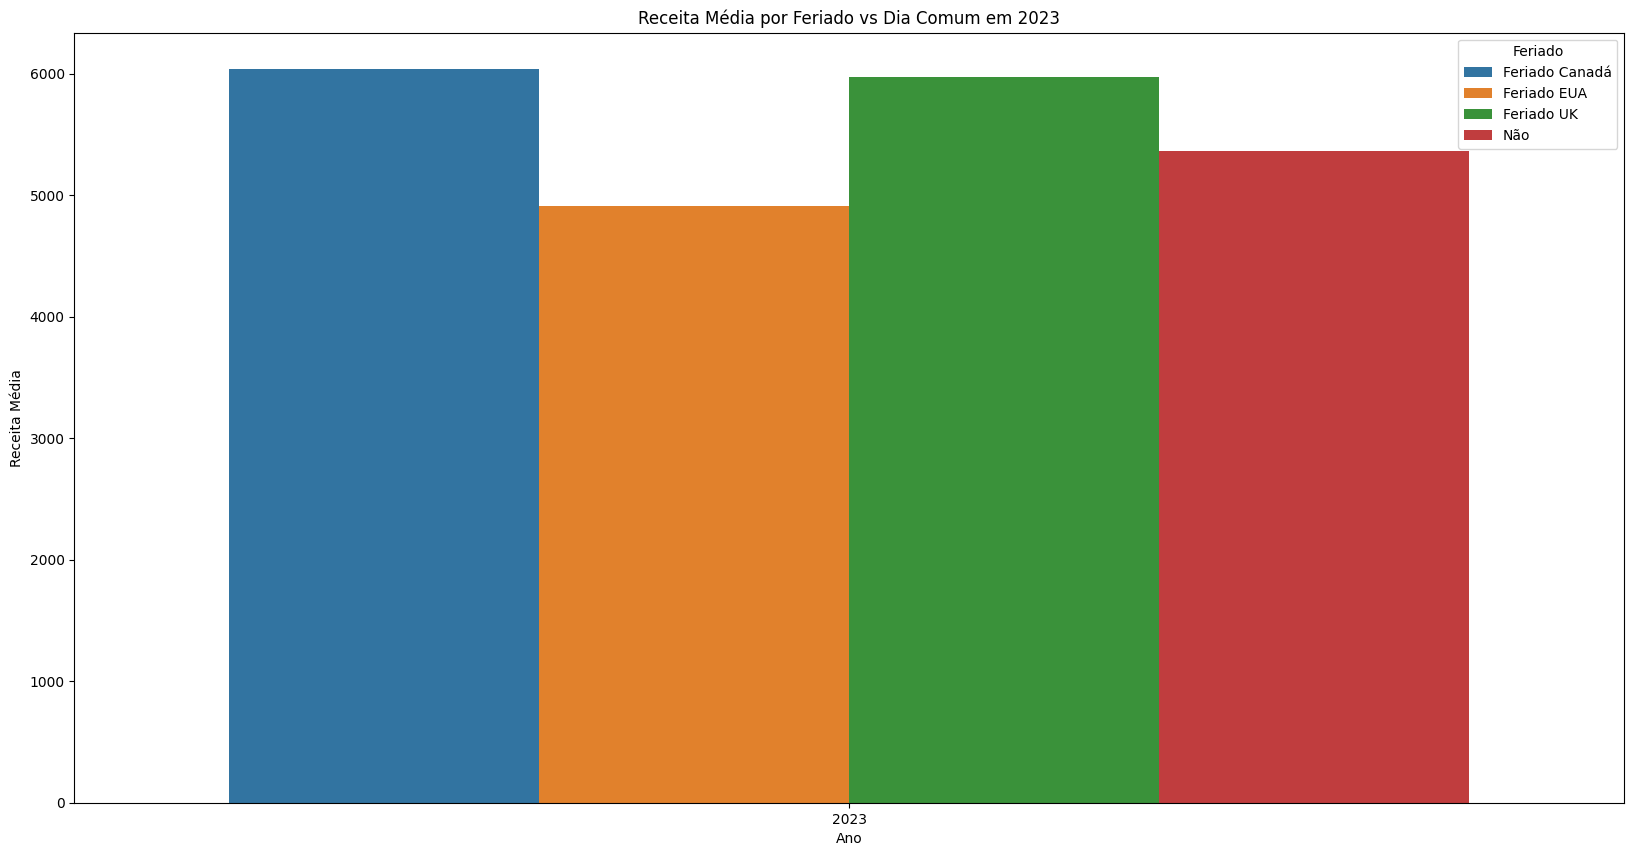

In [18]:
df_2023 = df[df['year'] == 2023]

resumo_feriado_ano_2023 = df_2023.groupby(['year', 'Feriado'])['Revenue'].mean().reset_index()
plt.figure(figsize=(20, 10))

sns.barplot(x='year', y='Revenue', hue='Feriado', data=resumo_feriado_ano_2023)
plt.title('Receita Média por Feriado vs Dia Comum em 2023')
plt.ylabel('Receita Média')
plt.xlabel('Ano')
plt.show()

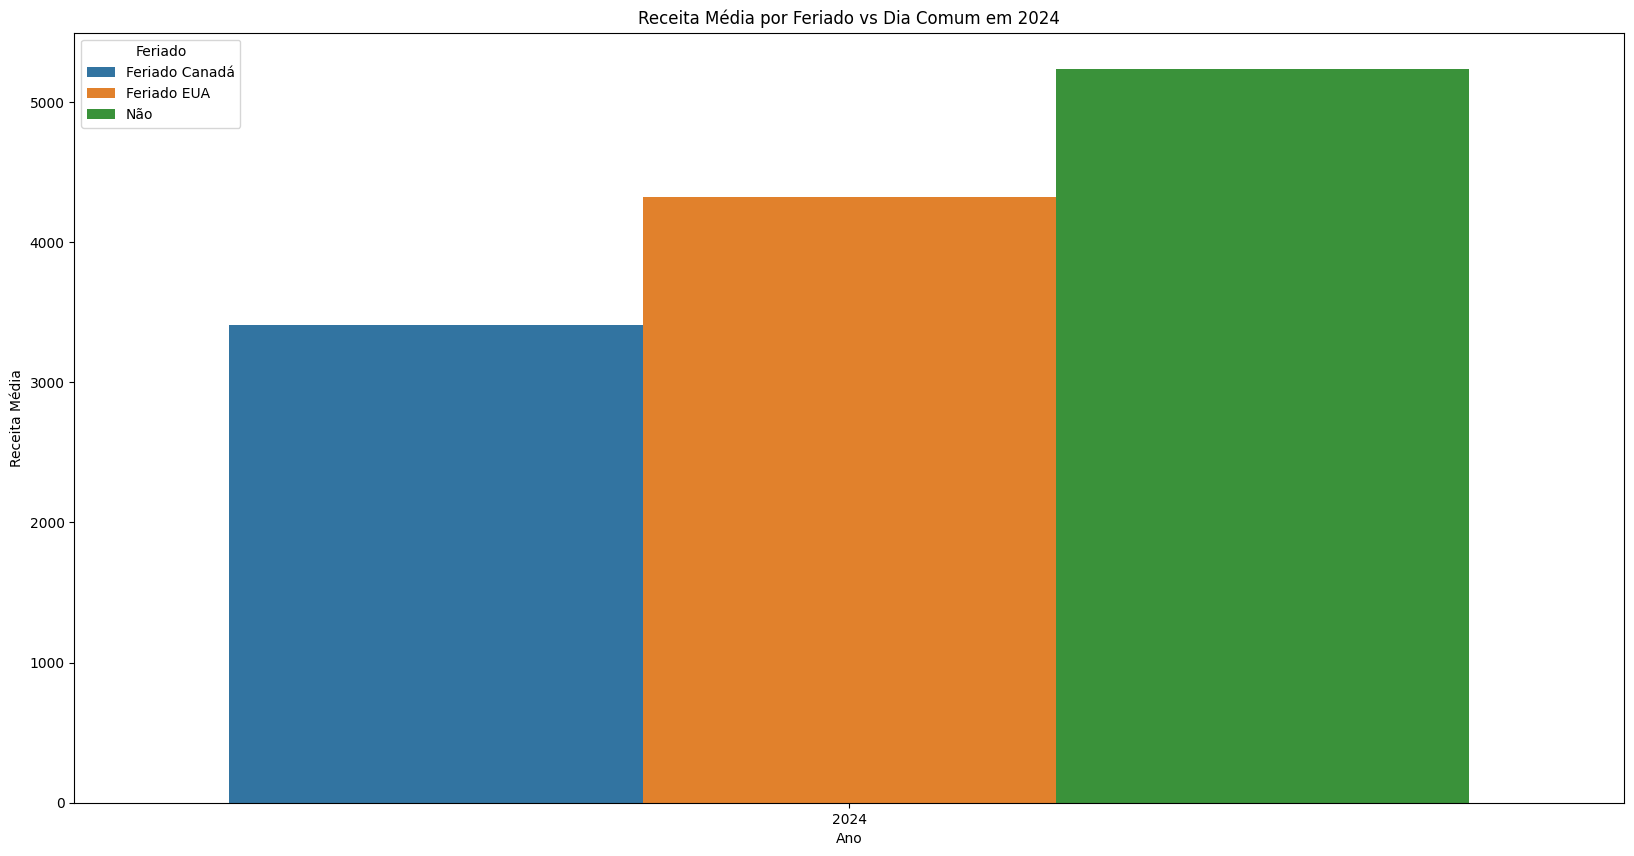

In [19]:
df_2024 = df[df['year'] == 2024]


resumo_feriado_ano_2024 = df_2024.groupby(['year', 'Feriado'])['Revenue'].mean().reset_index()
plt.figure(figsize=(20, 10))

sns.barplot(x='year', y='Revenue', hue='Feriado', data=resumo_feriado_ano_2024)
plt.title('Receita Média por Feriado vs Dia Comum em 2024')
plt.ylabel('Receita Média')
plt.xlabel('Ano')
plt.show()